# UW DRP 2026S Pairs Trading Project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import datetime as dt 
import talib as ta

In [ ]:
# Mock data
mock_ticker = yf.Ticker('SPY')
mock_start_date = dt.datetime.now() - dt.timedelta(days=8*365) # 8 yrs from today
mock_data = mock_ticker.history(start=mock_start_date)

In [ ]:
mock_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2018-06-25 00:00:00-04:00,242.097763,242.257125,238.255226,239.937439,137854200,0.000,0.0,0.0
2018-06-26 00:00:00-04:00,240.504142,241.318675,239.751565,240.468719,68547400,0.000,0.0,0.0
2018-06-27 00:00:00-04:00,241.053062,242.478508,238.326082,238.476608,105110700,0.000,0.0,0.0
2018-06-28 00:00:00-04:00,238.423523,240.601546,237.715204,239.840134,76650500,0.000,0.0,0.0
2018-06-29 00:00:00-04:00,240.929048,242.292537,240.070230,240.185333,97592500,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,752.611105,753.498832,747.953122,748.401978,67093100,0.000,0.0,0.0
2026-06-17 00:00:00-04:00,749.359442,750.217279,737.320450,739.056030,85945200,0.000,0.0,0.0
2026-06-18 00:00:00-04:00,747.760010,748.229980,743.859985,746.739990,80875700,1.904,0.0,0.0


In [ ]:
mock_data['RSI'] = ta.RSI(mock_data['Close'], timeperiod=14)
mock_buy_signals = mock_data[mock_data['RSI'] <= 30]
mock_sell_signals = mock_data[mock_data['RSI'] >= 70]

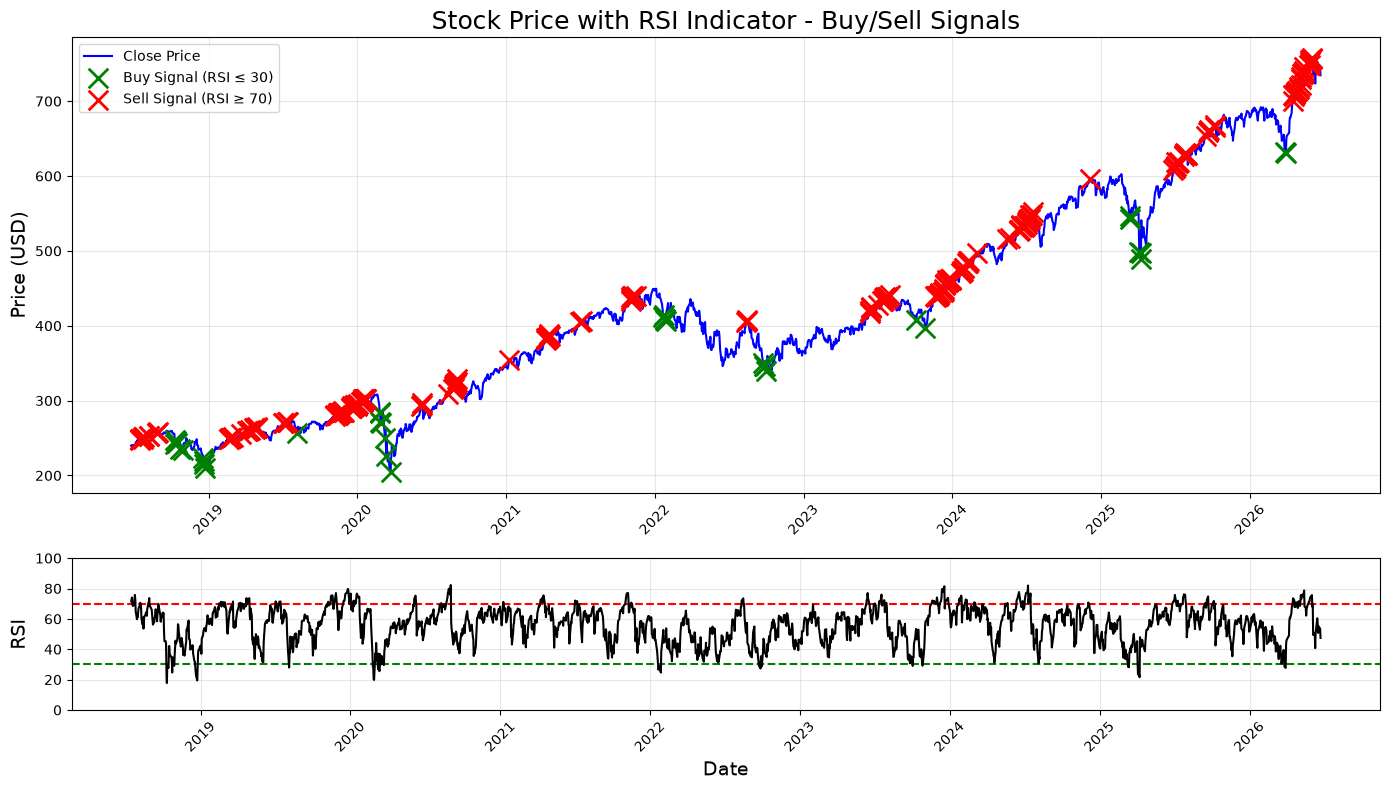

In [ ]:
fig, ax = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(14, 8))

# Top subplot: Close Price
ax[0].plot(mock_data['Close'], label='Close Price', linewidth=1.5, color='blue')

# Add buy signals (green X)
ax[0].scatter(mock_buy_signals.index, mock_buy_signals['Close'], marker='x', color='green', 
              s=200, linewidths=2, label='Buy Signal (RSI ≤ 30)', zorder=5)

# Add sell signals (red X)
ax[0].scatter(mock_sell_signals.index, mock_sell_signals['Close'], marker='x', color='red', 
              s=200, linewidths=2, label='Sell Signal (RSI ≥ 70)', zorder=5)

ax[0].set_title('Stock Price with RSI Indicator - Buy/Sell Signals', fontsize=18)
ax[0].set_ylabel('Price (USD)', fontsize=14)
ax[0].legend(fontsize=10, loc='upper left')
ax[0].grid(True, alpha=0.3)



# Bottom subplot: RSI
ax[1].axhline(y=70, color='red', ls='dashed', linewidth=1.5, label='Overbought (70)')
ax[1].axhline(y=30, color='green', ls='dashed', linewidth=1.5, label='Oversold (30)')
ax[1].plot(mock_data['RSI'], color='black', linewidth=1.5, label='RSI (14)')
ax[1].set_ylabel('RSI', fontsize=14)
ax[1].set_xlabel('Date', fontsize=14)
ax[1].set_ylim([0, 100])
#ax[1].legend(fontsize=10, loc='upper left')
ax[1].grid(True, alpha=0.3)

# Rotate x-axis labels for both subplots
plt.setp(ax[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

# 1. Pairs Statistics & Selection

Hello

In [ ]:
# Here is a comment 

# 2. Trading Strategy & Backtester

In [ ]:
import pandas as pd


def run_backtest(
    pair_data,
    entry_z=2.0,
    exit_z=0.5,
    transaction_cost=0.001
):
    """
    Run a simple pairs trading backtest.

    Required columns in pair_data:
        date
        pair
        price_1
        price_2
        hedge_ratio
        z_score

    Trading rules:
        z_score <= -entry_z:
            Enter long spread
            Long 1 unit of asset 1
            Short hedge_ratio units of asset 2

        z_score >= entry_z:
            Enter short spread
            Short 1 unit of asset 1
            Long hedge_ratio units of asset 2

        abs(z_score) <= exit_z:
            Exit the current position

    Parameters:
        entry_z:
            Z-score threshold for entering a trade.

        exit_z:
            Z-score threshold for exiting a trade.

        transaction_cost:
            Transaction cost as a proportion of traded notional.
            For example, 0.001 represents 0.1%.

    Returns:
        daily_results:
            Daily signals, positions, PnL and transaction costs.

        trade_log:
            Information about each completed trade.
    """

    # Make a copy so the original data is not changed
    pair_data = pair_data.copy()
    pair_data["date"] = pd.to_datetime(pair_data["date"])

    all_daily_results = []
    all_trades = []

    # Run the backtest separately for each pair
    for pair_name, data in pair_data.groupby("pair"):

        data = data.sort_values("date").reset_index(drop=True)

        # Position states:
        #  0 = no position
        #  1 = long spread
        # -1 = short spread
        position = 0

        entry_date = None
        entry_z_score = None
        entry_hedge_ratio = None
        entry_cost = 0
        trade_pnl = 0

        # for the data of the current pair we are dealing with.
        for i in range(len(data)):

            row = data.iloc[i]

            date = row["date"]
            price_1 = row["price_1"]
            price_2 = row["price_2"]
            z_score = row["z_score"]
            hedge_ratio = row["hedge_ratio"]

            signal = "HOLD"
            daily_pnl = 0
            cost = 0

            # ---------------------------------------------------------
            # Calculate today's PnL using the position held yesterday
            # ---------------------------------------------------------
            if i > 0 and position != 0:

                previous_row = data.iloc[i - 1]

                price_change_1 = (
                    price_1 - previous_row["price_1"]
                )

                price_change_2 = (
                    price_2 - previous_row["price_2"]
                )

                if position == 1:
                    # Long asset 1 and short asset 2
                    daily_pnl = (
                        price_change_1
                        - entry_hedge_ratio * price_change_2
                    )

                elif position == -1:
                    # Short asset 1 and long asset 2
                    daily_pnl = (
                        -price_change_1
                        + entry_hedge_ratio * price_change_2
                    )

                trade_pnl += daily_pnl

            # ---------------------------------------------------------
            # Enter a long-spread trade
            # ---------------------------------------------------------
            if position == 0 and z_score <= -entry_z:

                position = 1
                signal = "ENTER_LONG"

                entry_date = date
                entry_z_score = z_score

                # Keep the hedge ratio fixed until the trade exits
                entry_hedge_ratio = hedge_ratio
                trade_pnl = 0

                # calculating entry cost
                entry_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                entry_cost = (
                    transaction_cost * entry_notional
                )

                cost = entry_cost

            # ---------------------------------------------------------
            # Enter a short-spread trade
            # ---------------------------------------------------------
            elif position == 0 and z_score >= entry_z:

                position = -1
                signal = "ENTER_SHORT"

                entry_date = date
                entry_z_score = z_score
                entry_hedge_ratio = hedge_ratio
                trade_pnl = 0

                entry_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                entry_cost = (
                    transaction_cost * entry_notional
                )

                cost = entry_cost

            # ---------------------------------------------------------
            # Exit an existing trade
            # ---------------------------------------------------------
            elif position != 0 and abs(z_score) <= exit_z:

                signal = "EXIT"

                # calculating exit cost
                exit_notional = (
                    price_1
                    + abs(entry_hedge_ratio) * price_2
                )

                exit_cost = (
                    transaction_cost * exit_notional
                )

                cost = exit_cost

                # Net PnL after entry and exit transaction costs
                net_trade_pnl = (
                    trade_pnl
                    - entry_cost
                    - exit_cost
                )

                all_trades.append({
                    "pair": pair_name,
                    "entry_date": entry_date,
                    "exit_date": date,
                    "direction": (
                        "LONG_SPREAD"
                        if position == 1
                        else "SHORT_SPREAD"
                    ),
                    "entry_z": entry_z_score,
                    "exit_z": z_score,
                    "hedge_ratio": entry_hedge_ratio,
                    "gross_pnl": trade_pnl,
                    "transaction_cost": (
                        entry_cost + exit_cost
                    ),
                    "pnl": net_trade_pnl,
                    "holding_days": (
                        date - entry_date
                    ).days
                })

                # Reset the position after exiting
                position = 0
                entry_date = None
                entry_z_score = None
                entry_hedge_ratio = None
                entry_cost = 0
                trade_pnl = 0

            # Daily PnL after today's transaction cost
            net_daily_pnl = daily_pnl - cost

            # Store the current positions
            if position == 0:
                position_asset_1 = 0
                position_asset_2 = 0
            else:
                position_asset_1 = position
                position_asset_2 = (
                    -position * entry_hedge_ratio
                )

            all_daily_results.append({
                "date": date,
                "pair": pair_name,
                "z_score": z_score,
                "signal": signal,
                "position_asset_1": position_asset_1,
                "position_asset_2": position_asset_2,
                "daily_pnl": net_daily_pnl,
                "transaction_cost": cost
            })

    # Convert stored results into DataFrames
    daily_results = pd.DataFrame(all_daily_results)
    trade_log = pd.DataFrame(all_trades)

    # Calculate cumulative PnL separately for each pair
    if not daily_results.empty:
        daily_results["cumulative_pnl"] = (
            daily_results
            .groupby("pair")["daily_pnl"]
            .cumsum()
        )

    return daily_results, trade_log

# ---------------------------------------------------------
# Run the backtest
# ---------------------------------------------------------

# pair_data should be created by the pairs analysis section.
# It must contain:
# date, pair, price_1, price_2, hedge_ratio and z_score.
daily_results, trade_log = run_backtest(
    pair_data,
    entry_z=2.0,             # Enter a trade when |z-score| reaches 2.0
    exit_z=0.5,              # Exit when the spread returns close to its mean
    transaction_cost=0.001   # 0.1% transaction cost on traded notional
)


# ---------------------------------------------------------
# Preview the backtest outputs
# ---------------------------------------------------------

# Show the first five daily backtest records.
# This includes signals, positions, daily PnL and cumulative PnL.
print("Daily Results:")
print(daily_results.head())

# Show the first five completed trades.
# This includes entry/exit dates, direction, costs and trade PnL.
print("\nTrade Log:")
print(trade_log.head())

abs


# 3. Risk Engine

In [9]:
data = 14234

In [10]:
print(data)

14234


# 4. Robustness & Integration